# Burger's Equation FNO

Neural Operators are mappings between discretized function spaces, for example:

* Map from an initial condition to the solution function at a later point in time (or to the entire spatiotemporal solution funciton)
* Map from the function describing an inhomogeneous diffusivity distribution to the solution of the heat equation
* Autoregressive timesteppers, map state $u^{[t]}_h$ to state $u_h^{[t+1]}$

Fouries Neural Operators do so by employing the FFT to perform efficient **spectral convolution** taking into account global features. In that sense they are a multiscale architecture (Classical convolutional architectures are only local and their receptive field depends on the depth of the network).

Neural Operators allow for the solution of a whole parametric family of PDEs!

FNOs allow for **zero-shot superresolution**.

## Spectral Convolutions

Given the (real-valued) input discretized state $a$ (with potentially more than one channel) defined on an equidistant mesh; do the following steps:

1. Transform $a$ into Fourier space (here using the real-valued Fourier transform): $\hat{a} = \text{rfft}(a)$ (batch over the channel dimension)
2. Perform a batched matrix multiplication with a complex-valued weight vector $W$ for the first $K$ modes: $\hat{\tilde{a}}_{0:K} = W\hat{a}_{0:K}$
3. Set all the leftover modes to zero $\hat{\tilde{a}}_{K:} = 0 + 0i$
4. Transform back into real space $\tilde{a} = \text{irfft}(\hat{\tilde{a}})$

The learnable parameters for each spectral convolution are the complex-valued weight matrix of shape `(channels_out, channels_in, modes)` (Since it is complex-valued it actually has `2 * channels_out * channels_in * modes` real parameters)

## Fourier Neural Operator

A classical FNO consists of a lifting layer, multiple "ResNet"-like blocks of spectral convolutions with a bypass, and a projection layer. Projection and Lifting layer are 1x1 Convolutions to only modify the channel dimensions. The blocks operate as $b = \text{activation}(\tilde{a} + \text{Conv}_{1\times1}(a))$.


Here, we will mimic one example done in the original paper by [Li et al.](https://arxiv.org/pdf/2010.08895.pdf) as implemented in their [reference code](https://github.com/neuraloperator/neuraloperator/blob/af93f781d5e013f8ba5c52baa547f2ada304ffb0/fourier_1d.py) to solve the **1d Burgers equation**

$$ \frac{\partial u}{∂ t} + \frac{1}{2}\frac{\partial u^2}{\partial x} = \nu \frac{\partial^2 u}{\partial x^2} $$

The domain $\Omega = (0, 2 \pi)$ is periodic (i.e., $u(t, x=0) = u(t, x=2 \pi)$) and the diffusivity is fixed to $\nu=0.1$. Our dataset consists of $2048$ initial conditions $u(t=0, x)$ on a $N=8192$ resolution together with their solution at time one $u(t=1, x)$. The goal of the FNO is to learn the mapping from initial condition to state at time one using classical supervised learning. The input to the network is the input state channel-concatenated with the spatial coordinates of the meshpoints. The output is just the state at time one.

### Additional technicalities

* We train on the $32$-fold downsampled dataset (i.e., $256$ DoFs instead of $8192$)
	* Training is on the first 1000 data points
	* Validation/Testing is on the following 200 data points
* The FNO uses $16$ modes, $64$ hidden channels, and has four stacked spectral convolution blocks with bypass
* The dataset is reshuffled each epoch and the batch size is $100$
* We perform $200$ epochs in total
* Training is done with the Adam optimizer in default settings with a fixed learning rate of 3e-4

### Differences from the reference code

There are minor deviations from the [reference implementation](https://github.com/neuraloperator/neuraloperator/blob/af93f781d5e013f8ba5c52baa547f2ada304ffb0/fourier_1d.py), for example:

* Here, the dataset is preconcatenated with the mesh. The mesh is not concatenated with the input on the fly
* No activation in the projection layer. Instead the final Fourier block is activated.
* Anything I missed? I intended this script to be a pedagocial reduction, please let me know if there is an important detail I forgot.

# CylinderFNO (Karman Vortex)

In [2]:
import torch
import numpy as np
from repitframework.Models import FNO2D

# 2D Spectral Convolution: performs FFT --> Multiply by learned weights on low modes --> Inverse FFT
class SpectralConv2d(torch.nn.Module):
	def __init__(self, in_channels, out_channels, modes1, modes2):
		"""
		Parameters:
			in_channels  : Number of input channels. [width]
			out_channels : Number of output channels. [width]
			modes1       : Number of low-frequency modes to keep along the height dimension.
			modes2       : Number of low-frequency modes to keep along the width dimension.
		"""
		super().__init__()
		self.in_channels = in_channels
		self.out_channels = out_channels
		self.modes1 = modes1  # low freq modes in height
		self.modes2 = modes2  # low freq modes in width

		# Initialize weights with a small scaling factor; using torch.cfloat dtype
		self.scale = 1 / (in_channels * out_channels)
		self.weights1 = torch.nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, self.modes2, dtype=torch.cfloat))
		self.weights2 = torch.nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, self.modes2, dtype=torch.cfloat))


	def compl_mul2d(self, input, weights):
		# Performs batch-wise complex multiplication:
		# input: [B, C_in, H_ft, W_ft]
		# weights: [C_in, C_out, modes1, modes2]
		# Returns: [B, C_out, modes1, modes2]
		return torch.einsum("bchw,cohw->bohw", input, weights)

	def forward(self, x):
		"""
		x: Input tensor of shape [B, C_in, H, W]
		"""
		B, C, H, W = x.shape

		# Compute the 2D FFT (rfft2 returns output with shape [B, C, H, W//2 + 1])
		x_ft = torch.fft.rfft2(x)

		# Prepare an output tensor in Fourier space with the same shape as x_ft
		out_ft = torch.zeros(B, self.out_channels, H, W // 2 + 1,
							 dtype=x_ft.dtype, device=x.device)

		# Multiply only the lower frequency modes
		# Assumes that H and W are large enough so that modes1 and modes2 are within bounds.
		out_ft[:, :, :self.modes1, :self.modes2] = self.compl_mul2d(
			x_ft[:, :, :self.modes1, :self.modes2], self.weights1
		)
		out_ft[:, :, -self.modes1:, :self.modes2] = self.compl_mul2d(
			x_ft[:, :, -self.modes1:, :self.modes2], self.weights2
		)

		# Return to spatial domain using the inverse FFT
		x_out = torch.fft.irfft2(out_ft, s=(H, W))
		return x_out

class MLP(torch.nn.Module):
	def __init__(self, in_channels, out_channels, mid_channels):
		super(MLP, self).__init__()
		self.mlp1 = torch.nn.Conv2d(in_channels, mid_channels, 1)
		self.mlp2 = torch.nn.Conv2d(mid_channels, out_channels, 1)

	def forward(self, x):
		x = self.mlp1(x)
		x = torch.functional.F.gelu(x)
		x = self.mlp2(x)
		return x

# # Fourier layer for 2D inputs: combines the spectral convolution with a pointwise convolution
# class FNO2D(torch.nn.Module):
#     def __init__(self, 
#                  input_channels=10, 
#                  output_channels=1, 
#                  modes1=12, modes2=12, 
#                  width=20, 
#                  depth=4, 
#                  activation=torch.functional.F.gelu,
#                  x_coords=None,
#                  y_coords=None):
#         """
#         Parameters:
#             in_channels  : Number of channels entering the layer.
#             out_channels : Number of channels leaving the layer.
#             modes1, modes2 : Low-frequency modes to use along height and width.
#             activation   : Activation function.
#         """
#         super().__init__()
#         self.input_channels = input_channels
#         self.output_channels = output_channels
#         self.modes1 = modes1
#         self.modes2 = modes2
#         self.width = width
#         self.depth = depth
#         self.activation = activation
#         self.x_coords = x_coords
#         self.y_coords = y_coords


#         self.p = torch.nn.Linear(self.input_channels, self.width) # input channel is 12: the solution of the previous 10 timesteps + 2 locations (u(t-10, x, y), ..., u(t-1, x, y),  x, y)


#         self.norm= torch.nn.InstanceNorm2d(self.width)
#         self.spectral = torch.nn.ModuleList(
#             [SpectralConv2d(self.width, self.width, self.modes1, self.modes2) for _ in range(depth)]
#         )
#         self.pointwise = torch.nn.ModuleList(
#             [torch.nn.Conv2d(self.width, self.width, 1) for _ in range(depth)]
#         )
#         self.ws = torch.nn.ModuleList(
#             [torch.nn.Conv2d(self.width, self.width, 1) for _ in range(depth)]
#         )

#         self.q = MLP(self.width, output_channels, self.width*self.depth)

#     def forward(self, x:torch.Tensor):
#         # Apply spectral convolution and pointwise convolution separately and add them
#         grid = self.get_grid(x.shape, x.device)
#         x = torch.cat((x, grid), dim=1)  # Concatenate grid coordinates to input
#         x = x.permute(0, 2, 3, 1)  # Change to [B, H, W, C] for lifting.
#         x = self.p(x)
#         x = x.permute(0, 3, 1, 2)

#         for i in range(self.depth):
#             x1 = self.norm(self.spectral[i](self.norm(x)))
#             x1 = self.pointwise[i](x1)
#             x2 = self.ws[i](x)
#             x = x1 + x2
#             if i < self.depth - 1:
#                 x = self.activation(x)
#         x = self.q(x)
#         return x
	
#     def get_grid(self, shape, device):
#         batchsize, size_x, size_y = shape[0], shape[-2], shape[-1]
#         if self.x_coords is None or self.y_coords is None:
#             gridx = torch.tensor(np.linspace(0, 1, size_x), dtype=torch.float)
#             gridy = torch.tensor(np.linspace(0, 1, size_y), dtype=torch.float)
#         else:
#             gridx = torch.tensor(self.x_coords, dtype=torch.float)
#             gridy = torch.tensor(self.y_coords, dtype=torch.float)
#         gridx = gridx.reshape(1, 1, size_x, 1).repeat([batchsize, 1, 1, size_y])
#         gridy = gridy.reshape(1, 1, 1,size_y).repeat([batchsize, 1, size_x, 1])
#         return torch.cat((gridx, gridy), dim=1).to(device)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from timeit import default_timer
import json
import os
from repitframework.Models import FNO2D

class LpLoss(object):
	def __init__(self, d=2, p=2, size_average=True, reduction=True):
		super(LpLoss, self).__init__()

		#Dimension and Lp-norm type are postive
		assert d > 0 and p > 0

		self.d = d
		self.p = p
		self.reduction = reduction
		self.size_average = size_average

	def abs(self, x, y):
		num_examples = x.size()[0]

		#Assume uniform mesh
		h = 1.0 / (x.size()[1] - 1.0)

		all_norms = (h**(self.d/self.p))*torch.norm(x.view(num_examples,-1) - y.view(num_examples,-1), self.p, 1)

		if self.reduction:
			if self.size_average:
				return torch.mean(all_norms)
			else:
				return torch.sum(all_norms)

		return all_norms

	def rel(self, x, y):
		num_examples = x.size()[0]

		diff_norms = torch.norm(x.reshape(num_examples,-1) - y.reshape(num_examples,-1), self.p, 1)
		y_norms = torch.norm(y.reshape(num_examples,-1), self.p, 1)

		if self.reduction:
			if self.size_average:
				return torch.mean(diff_norms/y_norms)
			else:
				return torch.sum(diff_norms/y_norms)

		return diff_norms/y_norms

	def __call__(self, x, y):
		return self.rel(x, y)
	

data_path1 = "/home/shared_resource/2D_VSMR_structure_data/structure_vsmr_press_ic010_to_060_except040.npz"
data_path2 = "/home/shared_resource/2D_VSMR_structure_data/structure_vsmr_press_ic040.npz"
data_path3 = "/home/shared_resource/2D_VSMR_structure_data/structure_vsmr_press_ic060.npz"
data_path4 = "/home/shared_resource/2D_VSMR_structure_data/structure_vsmr_press_ic070.npz"

In [4]:
class FNODataset(torch.utils.data.Dataset):
	def __init__(self, data_path, t_input=10):
		self.data_path = data_path
		self.t_input = t_input
		self.data = np.load(data_path)

	def get_dataset(self, data_key="outputs"):
		data = self.data[data_key]

		ntrain = int(0.8 * len(data))
		ntest = len(data) - ntrain

		T = data.shape[1]
		T_in = self.t_input

		train_input = data[:ntrain, :T_in, ...]
		train_label = data[:ntrain, T_in:T, ...]

		test_input = data[-ntest:, :T_in, ...]
		test_label = data[-ntest:, T_in:T, ...]

		return train_input, train_label, test_input, test_label
	
	def get_dataloader(self, batch_size=32, step_size=1):

		train_input, train_label, test_input, test_label = self.get_dataset()

		train_dataset = torch.utils.data.TensorDataset(
			torch.tensor(train_input[:, :, ::step_size, ::step_size], dtype=torch.float32),
			torch.tensor(train_label[:, :, ::step_size, ::step_size], dtype=torch.float32)
		)
		test_dataset = torch.utils.data.TensorDataset(
			torch.tensor(test_input[:, :, ::step_size, ::step_size], dtype=torch.float32),
			torch.tensor(test_label[:, :, ::step_size, ::step_size], dtype=torch.float32)
		)

		train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
		test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

		return train_loader, test_loader
	
	def get_coordinates(self):
		data = self.data
		if 'x_coords' in data and 'y_coords' in data:
			return data['x_coords'], data['y_coords']
		else:
			raise KeyError("Coordinates not found in the dataset.")
	

def log_metrics(key:str, value:int|float, metrics_type:str="training"):
	logging_path = f"{metrics_type}_metrics.ndjson"
	
	# build a single JSON record for this metric
	record = {"key": key, "value": value}
	
	# append one JSON object per line
	with open(logging_path, "a") as f:
		f.write(json.dumps(record) + "\n")

dataset = FNODataset(data_path1, t_input=10)
# Get coordinates
x_coords, y_coords = dataset.get_coordinates()

In [5]:
class FNO2DTrainer:
	def __init__(self, 
			  input_channels=1, 
			  output_channels=100, 
			  modes1=12, modes2=12, 
			  width=128, 
			  depth=4,
			  t_input=10,
			  learning_rate=0.001,
			  x_coords=None,
			  y_coords=None):
		self.model = FNO2D(input_channels=input_channels, output_channels=output_channels,
						   modes1=modes1, modes2=modes2, width=width, depth=depth,
						   x_coords=x_coords,
						   y_coords=y_coords)
		self.t_input = t_input
		self.optimizer = torch.optim.Adam(self.model.parameters(), lr=learning_rate, weight_decay=1e-4)
		self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(self.optimizer, T_max=10)
		self.criterion = LpLoss(size_average=False)
		self.device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
		self.model.to(self.device)

	def predict(self, input_tensor:torch.Tensor, ic:str="0.4"):
		model:torch.nn.Module = self.load_model("best_model_FNO2D_cylinder.pth")
		model.eval()
		running_time = input_tensor.shape[1]+1
		save_path = "./data/predictions"
		os.makedirs(save_path, exist_ok=True)
		with torch.inference_mode():
			assert input_tensor.ndim == 4, "Input tensor must be 4D (B, C, H, W)"
			
			input_tensor = input_tensor.to(self.device)
			# Predict the next time step
			y_pred = model(input_tensor)
			np.save(f"{save_path}/predictions_{ic}.npy", y_pred.cpu().numpy())  # Save the prediction if needed
			# Append the prediction to the input tensor
			# input_tensor = torch.cat((input_tensor[:, 1:, ...], y_pred), dim=1)
			# running_time += 1
		return running_time
			

	def training_loop(self, data_loader):
		step_loss = 0.0
		for xx, yy in data_loader:
			loss = 0.0 
			xx = xx.to(self.device)
			yy = yy.to(self.device)

			for t in range(0, xx.shape[1], 1):
				y = yy[:, t:t + 1, :, :]
				y_pred = self.model(xx)

				loss += self.criterion(y_pred.reshape(y_pred.shape[0], -1), y.reshape(y.shape[0], -1))

				xx = torch.cat((xx[:, 1:, ...], y_pred), dim=1)
			step_loss += loss.item()
			if self.model.training:
				self.optimizer.zero_grad()
				loss.backward()
				self.optimizer.step()

				self.scheduler.step()

		return step_loss
	
	def train(self, train_loader, test_loader, epochs=1000):
		
		validation_loss = float('inf')
		for epoch in range(epochs):
			self.model.train()
			training_start = default_timer()

			train_l2_step_loss = self.training_loop(train_loader)

			self.model.eval()
			with torch.no_grad():
				test_l2_step_loss = self.training_loop(test_loader)
			if test_l2_step_loss < validation_loss:
				self.save_model("best_model_FNO2D_cylinder.pth")
				validation_loss = test_l2_step_loss

			training_end = default_timer()
			print(f", Time taken: {training_end - training_start:.2f} seconds")
			print(f"Epoch {epoch}: Training Loss: {train_l2_step_loss}, Validation Loss: {test_l2_step_loss}",  end='', flush=True)
			
			log_metrics("train_loss", train_l2_step_loss, "training")
			log_metrics("validation_loss", test_l2_step_loss, "validation")
			log_metrics("epoch", epoch, "training")

	def save_model(self, path):
		torch.save(
			{"model_dict":self.model.state_dict(),
				"optimizer_dict":self.optimizer.state_dict(),
				"scheduler_dict":self.scheduler.state_dict()
			}, path)
		print(f"Model saved to {path}")

	def load_model(self, path):
		checkpoint = torch.load(path, map_location=self.device, weights_only=True)
		self.model.load_state_dict(checkpoint["model_dict"])
		if "optimizer_dict" in checkpoint:
			self.optimizer.load_state_dict(checkpoint["optimizer_dict"])
		if "scheduler_dict" in checkpoint:
			self.scheduler.load_state_dict(checkpoint["scheduler_dict"])
		self.model.to(self.device)
		print(f"Model loaded from {path}")
		return self.model

	
	def fit(self, train_loader, test_loader, epochs=1000):
		metrics = self.train(train_loader, test_loader, epochs)
		return metrics
	
step_size = 2  # Adjust step size as needed
cylinderFNO = FNO2DTrainer()
vel_04 = np.load(data_path2)
# vel_04_input = np.expand_dims(vel_04["inputs"], axis=1)  # Add a channel dimension if needed
# vel_06 = np.load(data_path3)['outputs']
# vel_07 = np.load(data_path4)['outputs']
# train_loader, test_loader = dataset.get_dataloader(batch_size=10, step_size=step_size)
# cylinderFNO.fit(train_loader, test_loader, epochs=5000)
# cylinderFNO.predict(torch.tensor(vel_04_input, dtype=torch.float32), ic="0.4")

In [10]:
predicted_output = np.load("/home/shilaj/repitframework/random/data/predictions/predictions_0.4_128width.npy")

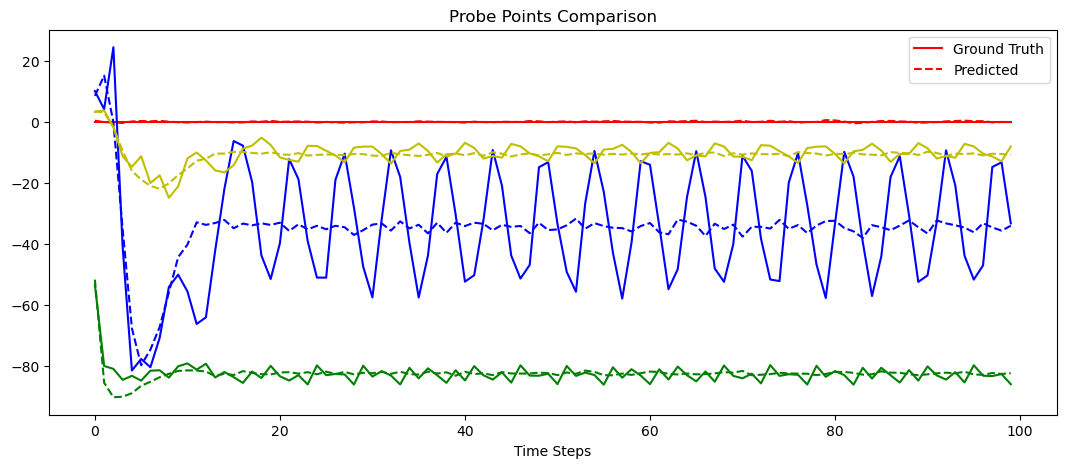

In [11]:
import matplotlib.pyplot as plt
import numpy as np

def plot_probe_points(ground_truth:np.ndarray,
                      predicted:np.ndarray,
                      locations:tuple=((120,141),(220,141), (320,141), (420,141))):
    fig, ax = plt.subplots(1, 1, figsize=(13, 5))
    ax = np.atleast_1d(ax)

    colors_list = ['r', 'g', 'b', 'y']

    for i, (x, y) in enumerate(locations):
        # Only add labels on the first iteration to avoid duplicate legend entries
        if i == 0:
            ax[0].plot(ground_truth[0, :, x, y], color=colors_list[i], label='Ground Truth')
            ax[0].plot(predicted[0, :, x, y], color=colors_list[i], linestyle='--', label='Predicted')
        else:
            # Plot the rest of the lines without labels
            ax[0].plot(ground_truth[0, :, x, y], color=colors_list[i])
            ax[0].plot(predicted[0, :, x, y], color=colors_list[i], linestyle='--')

    # Add the legend to the plot
    ax[0].legend()
    
    plt.title("Probe Points Comparison")
    plt.xlabel("Time Steps")
    plt.savefig("probe_points_0.4_not_padded.png")
    
plot_probe_points(vel_04["outputs"], predicted_output, locations=((110,141),(210,141), (310,141), (410,141)))


In [ ]:
# Write a function that takes to matrix as inputs and plots both of them side by side.
def plot_matrices(matrix1, matrix2, title1="Matrix 1", title2="Matrix 2"):
	fig, axes = plt.subplots(1, 2, figsize=(12, 6))
	axes[0].imshow(matrix1, cmap='viridis', aspect='auto')
	axes[0].set_title(title1)
	axes[0].axis('off')

	axes[1].imshow(matrix2, cmap='viridis', aspect='auto')
	axes[1].set_title(title2)
	axes[1].axis('off')

	plt.tight_layout()
	plt.show()

predicted_matrix = np.load("./data/predictions/predictions_99.npy")  # Load the prediction for time step 10

visualize_output("./data/predictions/predictions_99.npy", timestep=99, mode="image")

True

In [1]:
from repitframework.plot_utils import load_metrics
from pathlib import Path
import matplotlib.pyplot as plt


metrics =  load_metrics(Path("/home/shilaj/repitframework/random/training_metrics.ndjson"))


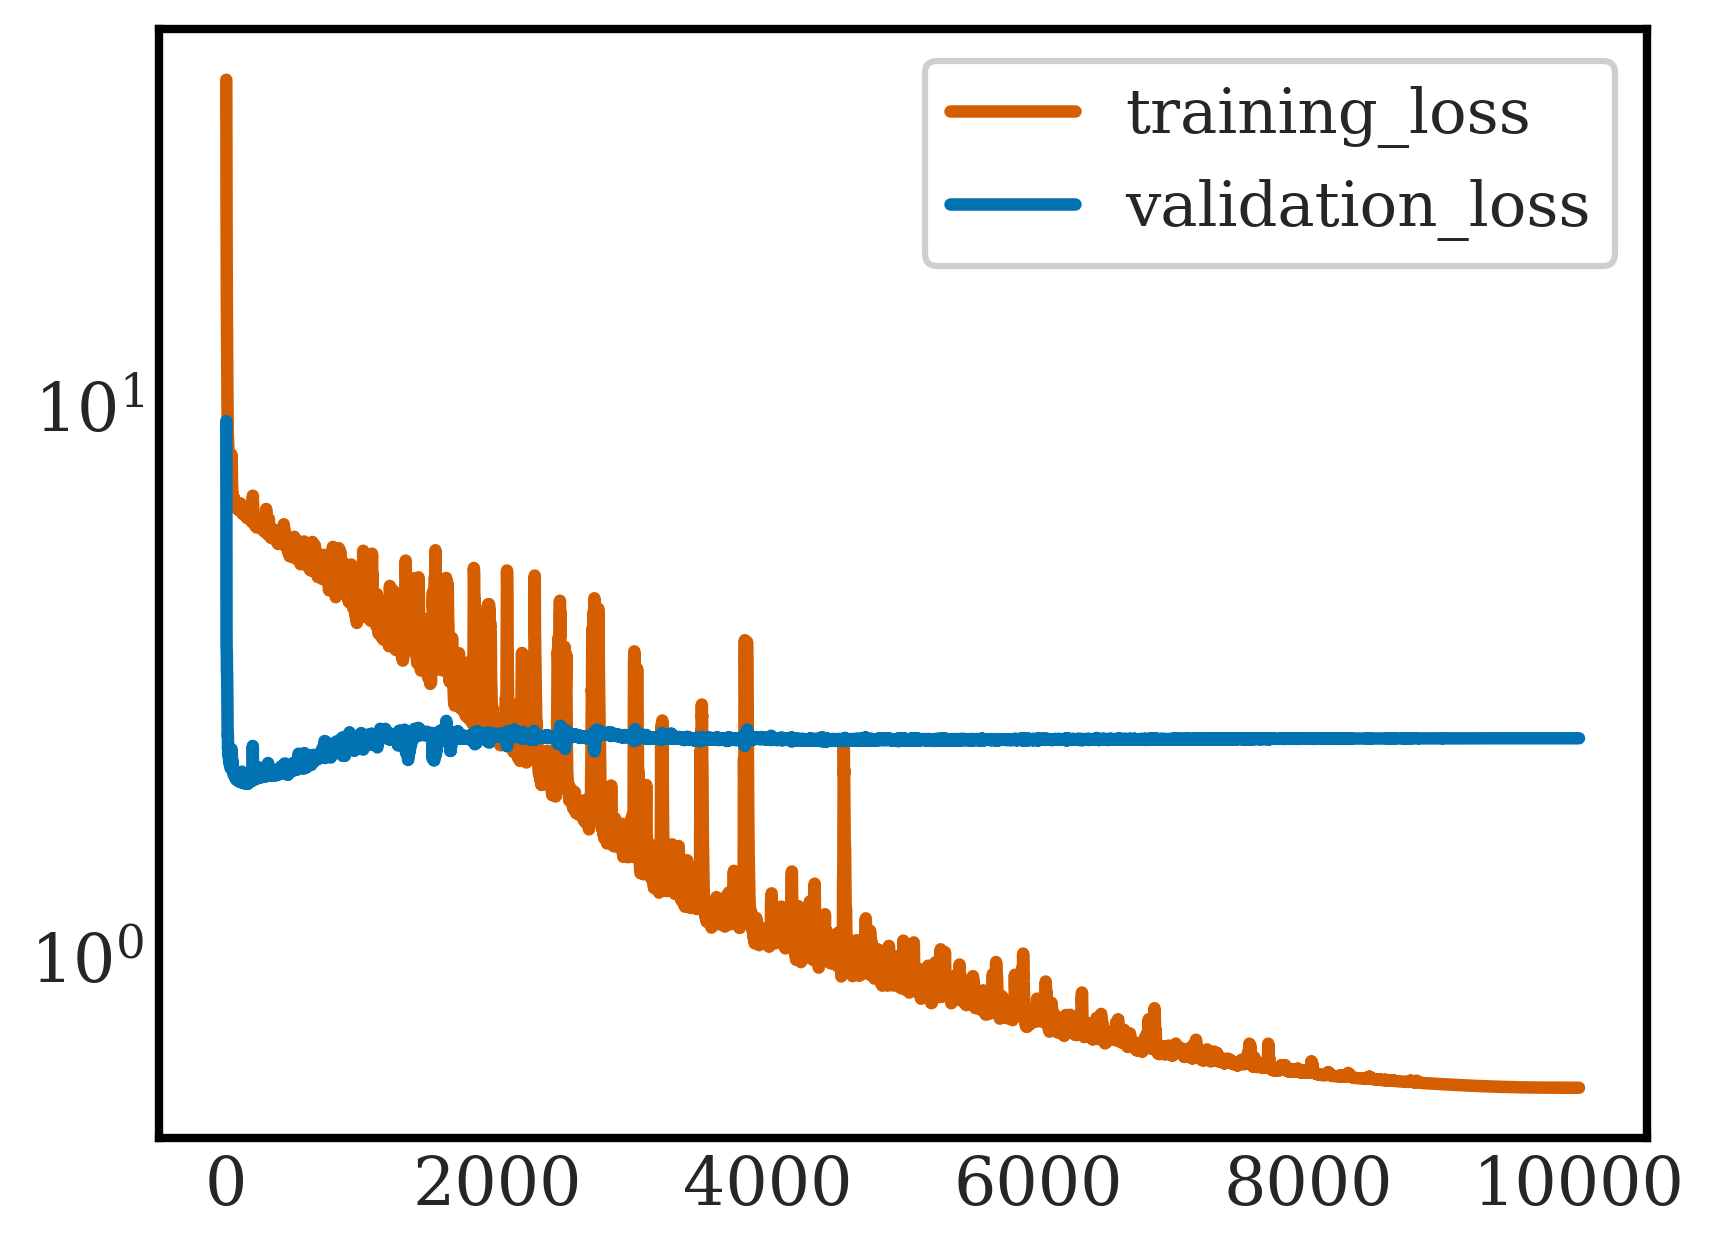

In [2]:
plt.plot(metrics["epoch"],metrics["train_loss"], label="training_loss", color="r")
plt.plot(metrics["epoch"], metrics["validation_loss"], label="validation_loss", color="b")
plt.yscale("log")
plt.legend()
plt.show()
# plt.savefig("cylinderFNO_loss.png", dpi=300)

In [9]:
import torch

random_input = torch.randn(50, 200,200)
random_output = torch.randn(50, 100, 200, 200)

train_mask = torch.ones(random_input.shape[0], dtype=bool)
test_mask = torch.zeros(random_input.shape[0], dtype=bool)

train_mask[::10] = False  # Set every 10th sample to False for training
test_mask[::10] = True    # Set every 10th sample to True for


In [16]:
random_input = random_input.unsqueeze(0)

mean = random_input.mean(dim=(0, 2, 3), keepdim=True)

In [1]:
from repitframework.Models import FNO2D, FVFNO2D, FVMNetwork,FVFNO1D


fno2d = FNO2D()
fvfno2d = FVFNO2D()
fvm_network = FVMNetwork()
fvfno1d = FVFNO1D()

In [2]:
print(f"FNO2D: {sum(p.numel() for p in fno2d.parameters())}")
print(f"FVFNO2D: {sum(p.numel() for p in fvfno2d.parameters())}")
print(f"FVMNetwork: {sum(p.numel() for p in fvm_network.parameters())}")
print(f"FVFNO1D: {sum(p.numel() for p in fvfno1d.parameters())}")

FNO2D: 1785798
FVFNO2D: 1696044
FVMNetwork: 1459071
FVFNO1D: 664899
